<a href="https://colab.research.google.com/github/swopnimghimire-123123/data-analysis-visualization/blob/main/07_IPL_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### IPL 2022 Capstone Project
**The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.**

**These are some of the important columns that we'll focus on for meaningful insights in this project.**

**column names: Variable Type**

- date : string
- venue : string
- stage : string
- team1 : string
- team2 : string
- toss_winner : string
- toss_decision : string
- first_ings_score : integer
- second_ings_score : integer
- match_winner : string
- won_by : string
- margin : integer
- player_of_the_match : string
- top_scorer : string
- highscore : integer
- best_bowling : string
- best_bowling_fgure : string
- gure : string

###**Loading the library and Dataset**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/IPL.csv")

In [ ]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


###**Basic Information**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

###**Check the size of rows and columns of the dataset**

In [ ]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns")

The dataset has 74 rows and 20 columns


Now let's see how many columns have null value in total

In [ ]:
df.isnull().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


##**Now here comes the basic questions.**

1. Which team won the most mathces?

In [ ]:
df["match_winner"]

,match_winner
0,Kolkata
1,Delhi
2,Punjab
3,Gujarat
4,Rajasthan
...,...
69,Punjab
70,Gujarat
71,Banglore
72,Rajasthan


In [ ]:
df["match_winner"].value_counts()

,count
match_winner,
Gujarat,12
Rajasthan,10
Banglore,9
Lucknow,9
Punjab,7
Delhi,7
Kolkata,6
Hyderabad,6
Chennai,4


In [ ]:
match_wins = df['match_winner'].value_counts()
most_wins_team = match_wins.idxmax()
most_wins_count = match_wins.max()

print(f"The team with the most wins is {most_wins_team} with {most_wins_count} wins.")

The team with the most wins is Gujarat with 12 wins.


Text(0, 0.5, 'Teams')

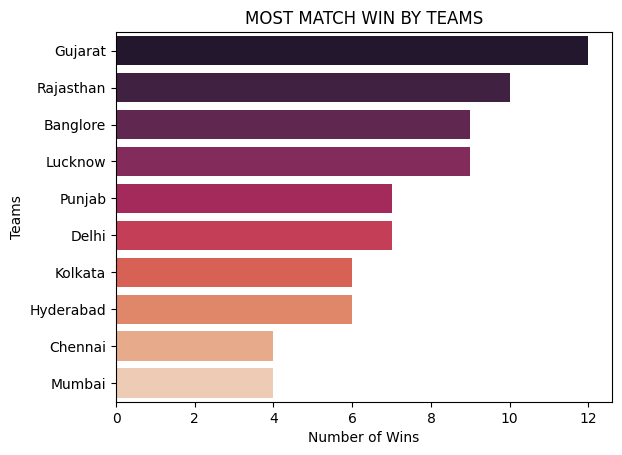

In [ ]:
match_wins = df["match_winner"].value_counts()
sns.barplot(y = match_wins.index, x = match_wins.values, palette = "rocket")
plt.title("MOST MATCH WIN BY TEAMS")
plt.xlabel("Number of Wins")
plt.ylabel("Teams")

2. Toss Decision Trends

Text(0, 0.5, 'Count')

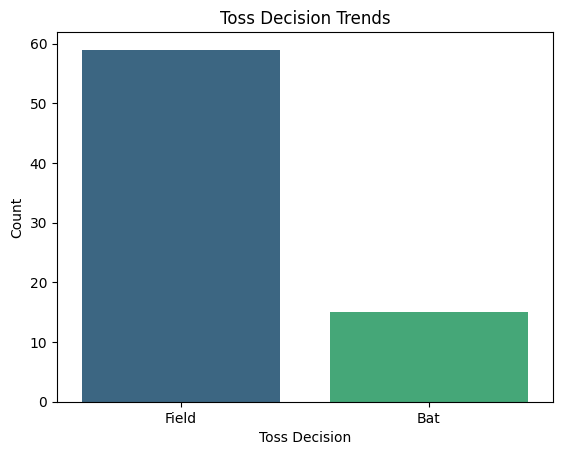

In [ ]:
sns.countplot( x = df["toss_decision"], palette="viridis")
plt.title("Toss Decision Trends")
plt.xlabel("Toss Decision")
plt.ylabel("Count")

3. Toss Wineer vs. Match Winner

In [ ]:
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count *100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

This code calculates the percentage of matches where the team that won the toss also won the match.

- `count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()`: This line filters the DataFrame `df` to select only the rows where the value in the 'toss_winner' column is equal to the value in the 'match_winner' column. Then, it selects the 'match_id' column of these filtered rows and counts the number of entries. This `count` represents the number of matches where the toss-winning team also won the match.

- `percentage = (count *100)/df.shape[0]`: This line calculates the percentage. It multiplies the `count` (number of matches where the toss winner also won) by 100 and then divides by the total number of rows in the DataFrame (`df.shape[0]`), which represents the total number of matches.

- `percentage.round(2)`: This line rounds the calculated percentage to two decimal places.

4. How do team win? (Runs vs Wickets)

In [ ]:
df["won_by"].head()

,won_by
0,Wickets
1,Wickets
2,Wickets
3,Wickets
4,Runs


Text(0.5, 1.0, 'WON BY')

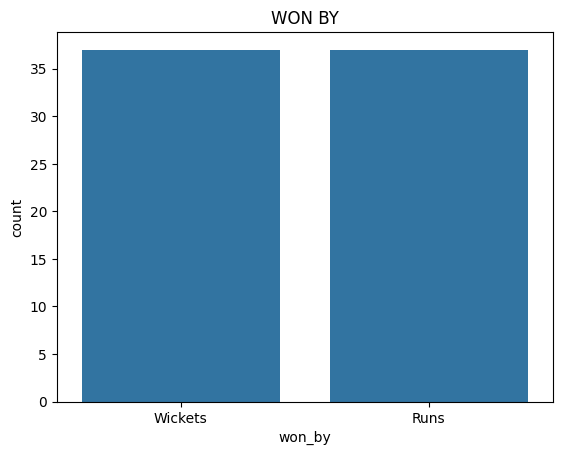

In [ ]:
sns.countplot(x = df["won_by"])
plt.title("WON BY")

### KEY PLAYER PERFORMANCE
1. Most "Player of the Match" Awards

In [ ]:
count = df["player_of_the_match"].value_counts().head(10)
count

,count
player_of_the_match,
Kuldeep Yadav,4
Jos Buttler,3
Wanindu Hasaranga,2
Umesh Yadav,2
Quinton de Kock,2
Shubman Gill,2
Avesh Khan,2
Dinesh Karthik,2
Hardik Pandya,2


Text(0, 0.5, 'Players')

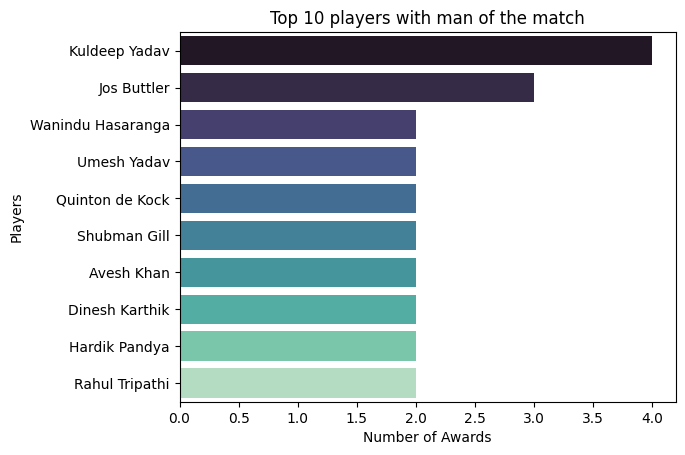

In [ ]:
sns.barplot(x = count.values , y = count.index,palette='mako')
plt.title("Top 10 players with man of the match")
plt.xlabel("Number of Awards")
plt.ylabel("Players")

2. Top Score

In [ ]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [ ]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high

,highscore
top_scorer,
Jos Buttler,651
Quinton de Kock,377


Text(0.5, 0, 'Player')

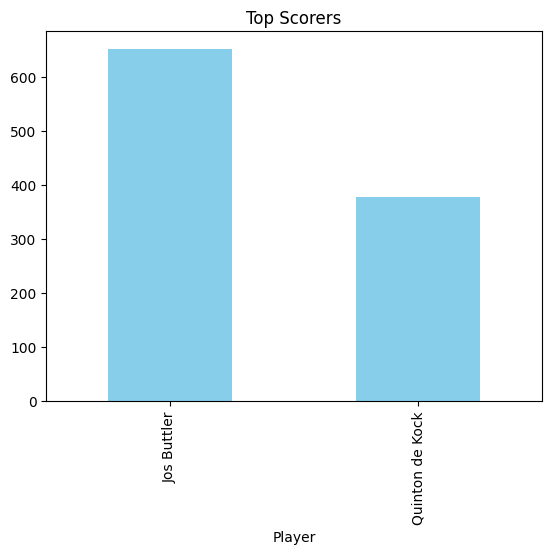

In [ ]:
high.plot(kind='bar', color='skyblue')
plt.title('Top Scorers')
plt.xlabel('Player')

10. Best Bowling Figures

In [ ]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


<Axes: ylabel='best_bowling'>

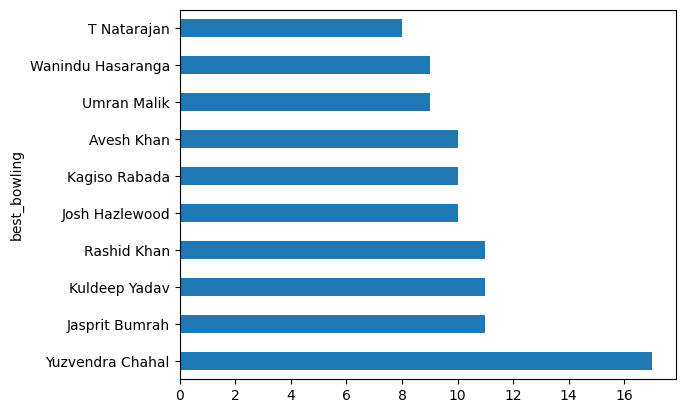

In [ ]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x :x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind = 'barh')

This code processes the 'best_bowling_figure' column to extract the number of wickets taken and then identifies the top 10 bowlers based on the total number of wickets.

- `df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x :x.split('--')[0])`: This line creates a new column called 'highest_wickets'. It applies a lambda function to each value in the 'best_bowling_figure' column. The lambda function splits each string by the '--' delimiter and takes the first part, which represents the number of wickets.

- `df['highest_wickets'] = df['highest_wickets'].astype(int)`: This line converts the data type of the 'highest_wickets' column from object (string) to integer, so that numerical operations can be performed on it.

- `top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)`: This line performs the following steps:
    - `df.groupby('best_bowling')`: Groups the DataFrame by the 'best_bowling' column (the name of the bowler).
    - `['highest_wickets'].sum()`: Calculates the sum of 'highest_wickets' for each bowler.
    - `.sort_values(ascending=False)`: Sorts the results in descending order based on the total number of wickets.
    - `.head(10)`: Selects the top 10 bowlers with the highest total wickets.

- `top_bowlers.plot(kind = 'barh')`: This line generates a horizontal bar plot of the `top_bowlers` data, visualizing the total number of wickets for the top 10 bowlers.

### Venue Analysis
Most Matches Played by Venue

In [ ]:
venue_count = df["venue"].value_counts()
venue_count

,count
venue,
"Wankhede Stadium, Mumbai",21
"Dr DY Patil Sports Academy, Mumbai",20
"Brabourne Stadium, Mumbai",16
"Maharashtra Cricket Association Stadium,Pune",13
"Eden Gardens, Kolkata",2
"Narendra Modi Stadium, Ahmedabad",2


Text(0, 0.5, 'Venue')

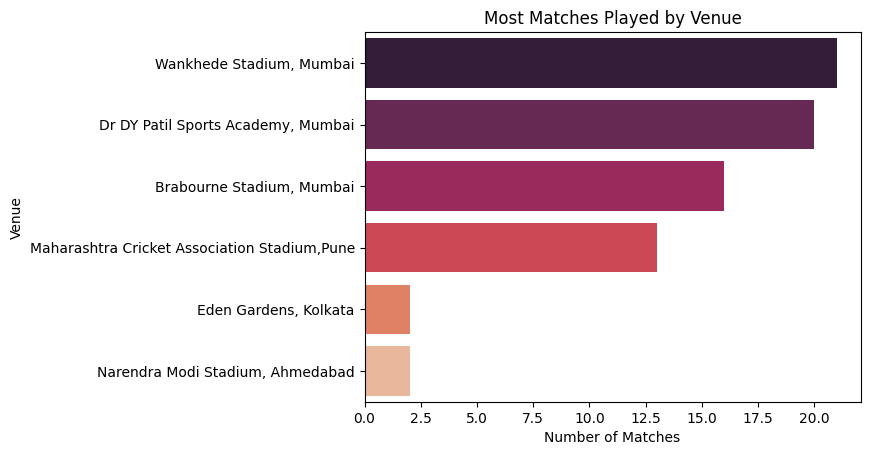

In [ ]:
sns.barplot(x = venue_count.values, y = venue_count.index, palette = "rocket")
plt.title("Most Matches Played by Venue")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")

Custom Questions and insights

Q1. Who won the highest margin by runs?

In [ ]:
df[df["won_by"] == "Runs"].sort_values(by="margin",ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


Q2. Which player had the highest individual score?

In [ ]:
df[df["highscore"]==df["highscore"].max()][["top_scorer","highscore"]]

,top_scorer,highscore
65,Quinton de Kock,140


Q3. Which bowler had the best bowling figures?

In [ ]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3


In [ ]:
df[df["highest_wickets"]==df["highest_wickets"].max()][["best_bowling","best_bowling_figure"]]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
